# 02_evaluate

Baseline raw/chat and one-shot/iterative runs are independent. Attach all four
saved outputs and the benchmark dataset. Paths are discovered through the helper.
AUP, DUR, category/library splits, Table III targets/tolerance, cost summary,
plots and insights retain the original evaluator. Raw baseline is for the
reproduction gate; intervention comparisons use matching chat configurations.

Table III is not meaningful on smoke. The original cost column `calls` counts
rows; per-row `num_calls` is retained for future analysis, not used here.

In [3]:
from deprecated_api.dataset import load_benchmark
from deprecated_api.evaluation import (
    comparison_table,
    cost_table,
    insights,
    per_library,
    plot_comparison,
    summarize,
    table_iii_gate,
)
from deprecated_api.pipeline import (
    BASELINE_RAW_STAGE,
    EVALUATE_STAGE,
    load_chained_results,
    prepare_stage,
    publish_stage,
    read_run_config,
    upstream_dir,
    write_keyed_results,
)

config = read_run_config(upstream_dir(BASELINE_RAW_STAGE))
SPLIT, LIMIT = config["split"], config["limit"]
_, items, HUMANEVAL = load_benchmark(SPLIT, LIMIT, config["sample_seed"])
config, all_results = load_chained_results(items)
RUNS = [tuple(run) for run in config["runs"]]
output = prepare_stage(EVALUATE_STAGE, config)

145 API mappings, 2101 prompts from 'sample' (limit=0, seed=42)


In [4]:
summaries = {key: summarize(rows) for key, rows in all_results.items()}
print(f"split={SPLIT} limit={LIMIT}\n")
comparison_table(summaries)
write_keyed_results(output / "comparison.json", summaries)

split=sample limit=0

method       model      mode       n  err  AUP(O)  AUP(U)  AUP(All)  DUR(O)  DUR(U)  DUR(All)
---------------------------------------------------------------------------------------------
baseline     deepseek   raw     2101    0    7.9%   11.6%      9.7%   72.6%    9.2%     35.3%
baseline     deepseek   chat    2101    0    1.5%    2.2%      1.9%   68.8%    8.7%     33.3%
baseline     gemini     chat    2101    0    9.4%   15.4%     12.3%   64.0%    3.8%     27.0%
verifier_one_shot deepseek   chat    2101    0    0.6%    2.0%      1.3%    0.0%    0.0%      0.0%
verifier_iterative deepseek   chat    2101    0    0.6%    2.0%      1.3%    0.0%    0.0%      0.0%
verifier_one_shot gemini     chat    2101    0    7.1%   15.4%     11.2%    6.6%    0.0%      2.1%
verifier_iterative gemini     chat    2101    0    7.1%   15.4%     11.2%    6.6%    0.0%      2.1%


In [5]:
gate = table_iii_gate(summaries)
per_library(summaries)

PASS  AUP_O    got=7.9 want=9.2 delta=1.3
PASS  AUP_U    got=11.6 want=11.8 delta=0.2
PASS  AUP_All  got=9.7 want=11.0 delta=1.3
PASS  DUR_O    got=72.6 want=69.7 delta=2.9
PASS  DUR_U    got=9.2 want=11.6 delta=2.4
FAIL  DUR_All  got=35.3 want=27.2 delta=8.1

OUT OF TOLERANCE -- see README/spec for the per-library deviation-hunting steps

=== baseline/deepseek/raw by library ===
lib                n     AUP     DUR
------------------------------------
numpy            300    2.3%    0.0%
pandas           138   22.5%   74.2%
pytorch          300   13.3%   52.5%
scipy            300    5.7%   41.2%
seaborn          300    7.0%    9.5%
sklearn          300   16.3%   18.4%
tensorflow       300   11.7%   17.1%
transformers     163    2.5%  100.0%

=== baseline/deepseek/chat by library ===
lib                n     AUP     DUR
------------------------------------
numpy            300    1.0%    0.0%
pandas           138    1.4%   50.0%
pytorch          300    3.0%   66.7%
scipy            30

## HumanEval model/mode control (optional)
This is the original full-function/pass@1 implementation, isolated for reuse.
It evaluates **model/mode behavior, not baseline-vs-verifier intervention**.
Enable explicitly to load models and run the existing control. It retains the
384-token budget, 10-second subprocess timeout, and chat signature limitation.

In [6]:
RUN_HUMANEVAL = False
if RUN_HUMANEVAL:
    import json
    import subprocess
    import sys

    from deprecated_api.backends import get_generate_fn
    from deprecated_api.config import IS_KAGGLE
    from deprecated_api.humaneval import report_humaneval, run_humaneval
    from deprecated_api.pipeline import apply_run_config

    if IS_KAGGLE:
        subprocess.check_call(
            [
                sys.executable,
                "-m",
                "pip",
                "install",
                "-q",
                "transformers",
                "accelerate",
                "google-genai",
            ]
        )
    apply_run_config(config)
    loaded = {}
    for model, mode in RUNS:
        if ("baseline", model, mode) in all_results and model not in loaded:
            try:
                loaded[model] = get_generate_fn(model)
            except Exception as exc:
                print(f"skipping HumanEval {model}: {exc!r}")
    he_results = run_humaneval(HUMANEVAL, RUNS, loaded, config["humaneval_limit"])
    report_humaneval(he_results)
    (output / "humaneval.json").write_text(
        json.dumps(
            [
                {"model": model, "mode": mode, "rows": rows}
                for (model, mode), rows in he_results.items()
            ],
            indent=2,
        )
        + "\n",
        encoding="utf-8",
    )

In [7]:
cost = cost_table(all_results, RUNS)
write_keyed_results(output / "cost.json", cost)

baseline: ('baseline', 'deepseek', 'raw')

method       model      mode    calls  tok_in tok_out   lat_ms  vs base
-----------------------------------------------------------------------
baseline     deepseek   raw      2101   180.9    50.0     1126    1.00x
baseline     deepseek   chat     2101   262.9    49.5     1145    1.02x
baseline     gemini     chat     2101   178.2    40.6      623    0.55x
verifier_one_shot deepseek   chat     2101   266.0    49.8     1212    1.08x
verifier_iterative deepseek   chat     2101   266.0    49.8     1222    1.08x
verifier_one_shot gemini     chat     2101   188.8    41.6      766    0.68x
verifier_iterative gemini     chat     2101   189.6    41.7      848    0.75x


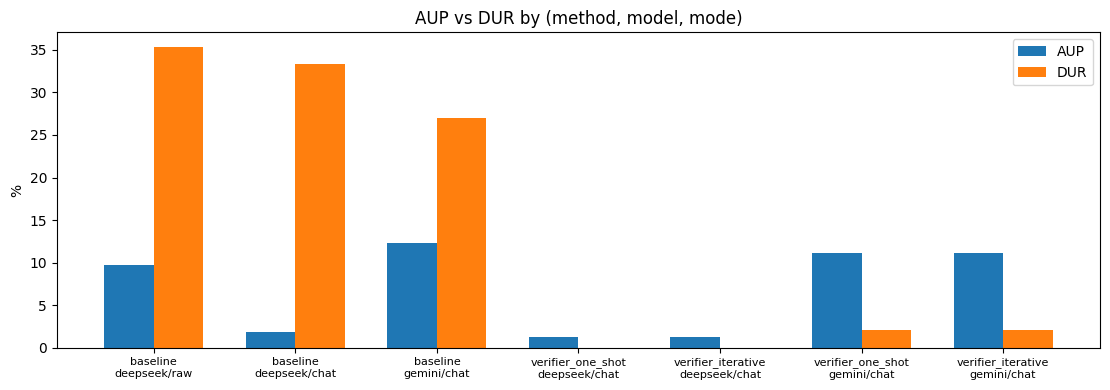

=== Insights ===
Lowest DUR (best):  ('verifier_one_shot', 'deepseek', 'chat') at 0.0%
Highest DUR (worst): ('baseline', 'deepseek', 'raw') at 35.3%
Highest AUP: ('baseline', 'gemini', 'chat') at 12.3%
verifier_one_shot vs baseline (deepseek/chat): DUR reduces by 33.3 points (0.0% vs 33.3%)
verifier_iterative vs baseline (deepseek/chat): DUR reduces by 33.3 points (0.0% vs 33.3%)
verifier_one_shot vs baseline (gemini/chat): DUR reduces by 24.9 points (2.1% vs 27.0%)
verifier_iterative vs baseline (gemini/chat): DUR reduces by 24.9 points (2.1% vs 27.0%)


PosixPath('/kaggle/working/artifacts/02_evaluate/manifest.json')

In [8]:
from deprecated_api.config import FIGURES_DIR

figure_dir = FIGURES_DIR / EVALUATE_STAGE
figure_dir.mkdir(parents=True, exist_ok=True)
figure_path = figure_dir / "comparison.png"
plot_comparison(summaries, figure_path)
insights(summaries)
publish_stage(EVALUATE_STAGE, figure=str(figure_path))